<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Value Based</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [54]:
# --- Standard Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
import matplotlib.cm as cm
from cycler import cycler
import geopandas as gpd
from matplotlib.lines import Line2D
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.base import clone

In [12]:
# Plot style configuration (unified look)
# Keeps logic intact; only global appearance defaults are set.

# Accessible, consistent palette
_palette = sns.color_palette("Set1", 10)
_palette_hex = _palette.as_hex()

# Seaborn / Matplotlib defaults
sns.set_theme(style="whitegrid", context="notebook", palette=_palette)
mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.color': '#EAEAEA',
    'grid.linestyle': '-',
    'grid.alpha': 0.6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.borderpad': 0.4,
    'legend.loc': 'best',
    'lines.linewidth': 2.0,
    'axes.prop_cycle': cycler('color', _palette_hex),
})


def make_palette_map(categories, palette_name="Set1", n_colors=None, as_hex=False):
    """
    Simple: returns (palette_map, palette_list).
    - categories: iterable (keeps first-seen order, coerces to str)
    - palette_name: seaborn palette name
    - n_colors: optional override (defaults to max(len(categories), 3))
    - as_hex: if True, return palette_map with hex strings
    """
    cats = [str(c) for c in dict.fromkeys(categories)]          # unique keep-order
    n_colors = n_colors or max(len(cats), 3)
    palette = sns.color_palette(palette_name, n_colors)
    palette_map = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}
    if as_hex:
        return {k: matplotlib.colors.to_hex(v) for k, v in palette_map.items()}, palette
    return palette_map, palette



# Plotly defaults (to align with seaborn/matplotlib)
px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = _palette_hex
px.defaults.color_continuous_scale = 'Cividis'
px.defaults.width = 900
px.defaults.height = 500


## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [13]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")

Found CSV files: ['DM_AIAI_CustomerDB_Cleaned_Featured.csv', 'DM_AIAI_FlightsDB_Cleaned_Featured.csv']


In [14]:
# specify the files we want to load
customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 46)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [15]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'City', 'Latitude', 'Longitude', 'Postal code', 'Income',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick', 'Province or State_Newfoundland',
       'Province or State_Nova Scotia', 'Province or State_Ontario',
     

In [16]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'Season'],
      dtype='object')

In [7]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,47.174418,-91.838613,37721.547359,7982.088433,0.874931,1104.017282,160.315874,34.035603,289943.099212,28988.602947,8601.144116,84.999084,8053.974942,0.286192,0.219317
std,258720.547621,3.306921,22.245806,30342.177810,6841.119253,0.330807,741.228136,67.910430,22.216511,162257.383492,16223.028595,8707.423785,86.110464,4507.149549,0.410727,0.128048
min,100018.000000,42.984924,-135.056840,0.000000,1898.010000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,44.231171,-120.237660,0.000000,3979.390000,1.000000,384.000000,121.640000,16.000000,153607.450000,15356.795000,0.000000,0.000000,4266.875000,0.000000,0.150407
50%,550434.000000,46.087818,-79.383186,34115.000000,5781.020000,1.000000,1032.000000,173.400000,35.000000,333555.500000,33350.310000,6627.000000,65.000000,9265.430000,0.217670,0.221622
75%,771330.000000,49.282730,-74.596184,62375.000000,8936.970000,1.000000,1754.000000,213.620000,50.000000,414067.300000,41400.130000,13663.850000,134.950000,11501.870000,0.420562,0.288889
max,999986.000000,60.721188,-52.712578,99981.000000,83325.380000,1.000000,2466.000000,340.000000,119.000000,712729.600000,71264.460000,57527.800000,572.000000,19798.040000,16.125899,1.000000


# 2. Clustering - Demographic <a class="anchor" id="data-validity-checks"></a>

We will do now the Clustering. This notebook will focus on Value Based Perspective for Clustering

We have to decide, which features we will use for Clustering from Demographic Perspective. 
We will use the following features for Clustering from Demographic Perspective:


- Country
- Proivince or State
- City
- Postal Code
- Location Code
- Latitude, Longitude
- Gender
- Education
- Income
- Maritial Status

We will not consider the following features:

- Country

All customers are from Canada, meaning the feature has no variability.
Including it would add no useful information for clustering.

- Postal Code

Postal codes are highly specific and almost unique per customer.
Because of this granularity, the feature would introduce noise rather than meaningful patterns.

- City

This feature is not required for our analysis purposes.
Removing it simplifies the dataset without losing relevant information.

In [17]:
original_features = [
    'Province or State',
    'Location Code',
    'Latitude',
    'Longitude',
    'Gender',
    'Education',
    'Income',
    'Marital Status'
]

In [31]:
demographic_features = []

for feature in original_features:
    
    # encoded columns
    encoded_cols = [
        col for col in customers.columns
        if col.startswith(f"{feature}_")
    ]
    
    # non-encoded column
    if feature in customers.columns:
        demographic_features.append(feature)
    
    # add encoded columns
    demographic_features.extend(encoded_cols)

# remove possible duplicates (safety)
demographic_features = list(dict.fromkeys(demographic_features))

# Show the selected featurescustomers[preference_features].head()
customers[demographic_features].head()

# Print number of metric features   
print ("Number of metric features:", len(demographic_features))

# check if metric or not 
for feature in demographic_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")

Number of metric features: 22
Province or State_British Columbia: Metric
Province or State_Manitoba: Metric
Province or State_New Brunswick: Metric
Province or State_Newfoundland: Metric
Province or State_Nova Scotia: Metric
Province or State_Ontario: Metric
Province or State_Prince Edward Island: Metric
Province or State_Quebec: Metric
Province or State_Saskatchewan: Metric
Province or State_Yukon: Metric
Location Code_Suburban: Metric
Location Code_Urban: Metric
Latitude: Metric
Longitude: Metric
Gender_male: Metric
Education_College: Metric
Education_Doctor: Metric
Education_High School or Below: Metric
Education_Master: Metric
Income: Metric
Marital Status_Married: Metric
Marital Status_Single: Metric


We need to scale the data before applying Clustering, but the scaling should be applied only to the non–one-hot encoded features.

# 3. Scaling

In [65]:
#scaler= StandardScaler()
scaler = MinMaxScaler() 


# Identify one-hot encoded demographic features (binary 0/1)
one_hot_demographic_features = [
    col for col in demographic_features
    if customers[col].dropna().isin([0, 1]).all()
]

# Identify non-one-hot demographic features (to be scaled)
non_one_hot_demographic_features = [
    col for col in demographic_features
    if col not in one_hot_demographic_features
]


# Scale only non-OHE demographic features
df_demographic = pd.DataFrame(
    scaler.fit_transform(customers[non_one_hot_demographic_features]),
    columns=non_one_hot_demographic_features,
    index=customers.index
)

# Add OHE demographic features back (unchanged)
df_demographic[one_hot_demographic_features] = customers[one_hot_demographic_features]
    
df_demographic.head()

,Latitude,Longitude,Income,Province or State_British Columbia,Province or State_Manitoba,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,...,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,Gender_male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single
0,0.037680,0.676108,0.701593,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
1,0.595360,0.261899,0.000000,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
2,0.355081,0.144954,0.000000,True,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,True
3,0.037680,0.676108,0.000000,False,False,False,False,False,True,False,...,False,True,False,True,True,False,False,False,False,True
4,0.137786,0.720675,0.978506,False,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False


# 4. Correlation Matrix

K-means is based on euclidean distance. When two features are highly correlated, they will have a higher impact on the distance calculation, which can skew the clustering results. Therefore, it is important to check for correlations among the features before applying K-means clustering. If we find highly correlated features, we might consider removing one of them.

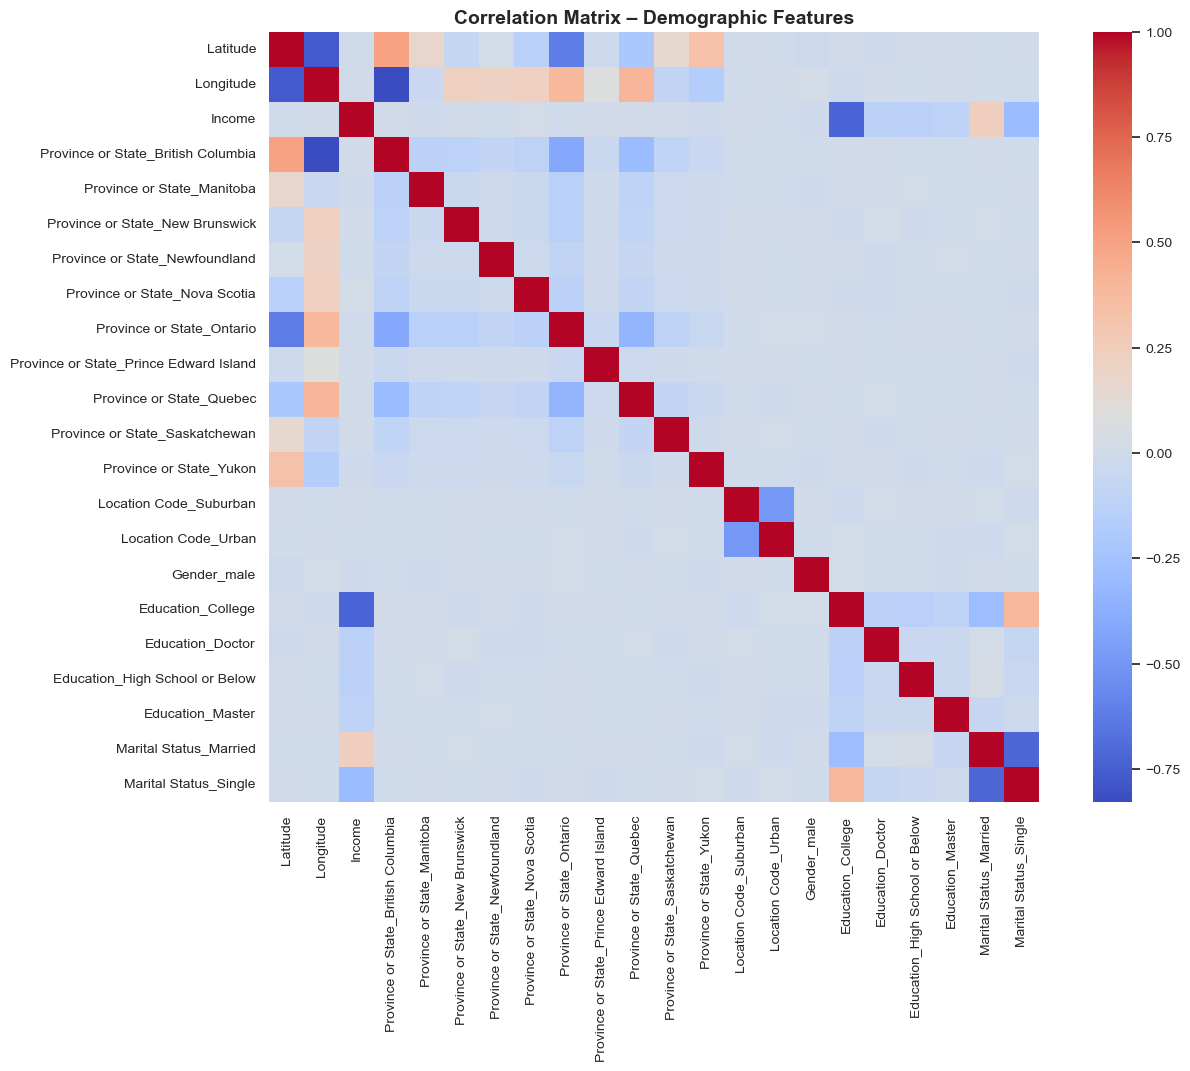

In [66]:
plt.figure(figsize=(14, 10))
correlation_matrix = df_demographic.corr()

sns.heatmap(
    correlation_matrix,
    annot=False, 
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix – Demographic Features")
plt.show()


The correlation matrix shows moderate correlations among continuous demographic variables and expected negative correlations between mutually exclusive one-hot encoded categories. No critical multicollinearity issues were identified

In [ ]:
threshold = 0.85
features_to_check = demographic_features

# Original categorical features that were one-hot encoded (base names)
ohe_base_features = [
    f for f in original_features
    if f not in ["Latitude", "Longitude", "Income"] 
]

# Build a map: each encoded column
col_to_base = {}
for base in ohe_base_features:
    prefix = f"{base}_"
    for col in customers.columns:
        if col.startswith(prefix):
            col_to_base[col] = base

# Correlation
df = customers[features_to_check].copy()
corr = df.corr(numeric_only=True)

# Take upper triangle only (avoid duplicates + self-corr)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find pairs above threshold
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
)
pairs["abs_corr"] = pairs["corr"].abs()
pairs = pairs[pairs["abs_corr"] >= threshold].sort_values("abs_corr", ascending=False)

# Filter out "expected OHE correlations"
def is_expected_ohe_corr(f1: str, f2: str) -> bool:
    # If both are one-hot columns and belong to the same original categorical base -> expected
    b1 = col_to_base.get(f1)
    b2 = col_to_base.get(f2)
    return (b1 is not None) and (b1 == b2)

pairs_filtered = pairs[~pairs.apply(lambda r: is_expected_ohe_corr(r["feature_1"], r["feature_2"]), axis=1)]

print(f"High-correlation pairs (|r| >= {threshold}) AFTER ignoring expected OHE within-group correlations: {len(pairs_filtered)}")
pairs_filtered.head()


High-correlation pairs (|r| >= 0.85) AFTER ignoring expected OHE within-group correlations: 0


""


Highly correlated continuous features may introduce redundancy and distort distance-based clustering. Therefore, correlation analysis was performed, but no features exceeded the defined threshold and all were retained.

# 5. Number of clusters

## 5.1 Cluster Number Selection Using R²-Based Evaluation

In [50]:
kmeans = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)


In [51]:
hierarchical = AgglomerativeClustering(
    metric='euclidean'
)

In [52]:
def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=2, max_k=15):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

In [ ]:
r2_scores = {}

r2_scores['kmeans'] = get_r2_scores(df_demographic, demographic_features, kmeans)

for linkage in ['complete', 'average', 'single', 'ward'] :  # 'complete', 'average', 'single', 'ward'
    r2_scores[linkage] = get_r2_scores(
        df_demographic,                 # data
        demographic_features,   # features of perspective
        # use HClust, changing the linkage at each iteration
        hierarchical.set_params(linkage=linkage)
    )


c:\Users\Duarte\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Duarte\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Duarte\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Duarte\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

In [57]:
r2_scores_df = pd.DataFrame(r2_scores)
r2_scores_df

,kmeans,complete,average,single,ward
2,0.156148,0.089168,0.005758,0.000103,0.105523
3,0.249396,0.165975,0.128845,0.009272,0.181595
4,0.319787,0.177697,0.131902,0.027591,0.236819
5,0.358314,0.189002,0.141337,0.029949,0.284424
6,0.386922,0.194650,0.239530,0.051312,0.325476
7,0.422112,0.269260,0.272806,0.051423,0.347758
8,0.446573,0.291158,0.275217,0.146668,0.369097
9,0.465826,0.299104,0.289969,0.146727,0.390142
10,0.478296,0.326400,0.335548,0.147310,0.409067
11,0.495749,0.332830,0.348602,0.147378,0.427420


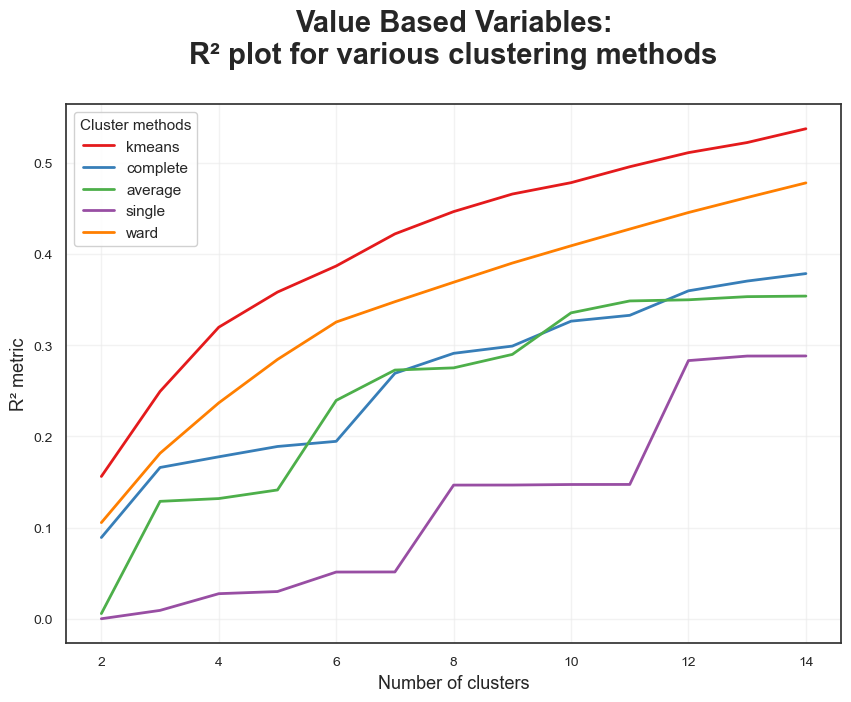

In [58]:
# Visualizing the R² scores for each cluster solution on value based variables
r2_scores_df.plot.line(figsize=(10,7))

plt.title("Value Based Variables:\nR² plot for various clustering methods\n", fontsize=21)
plt.legend(title="Cluster methods", title_fontsize=11)
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)
plt.show()

## 5.2 Silhouette Score Analysis

Calculating Silhouette Scores...
k=2: 0.1800
k=3: 0.1633
k=4: 0.1739
k=5: 0.1588
k=6: 0.1691
k=7: 0.1802
k=8: 0.1839
k=9: 0.1769
k=10: 0.1793
k=11: 0.1862
k=12: 0.1927
k=13: 0.1830
k=14: 0.1938


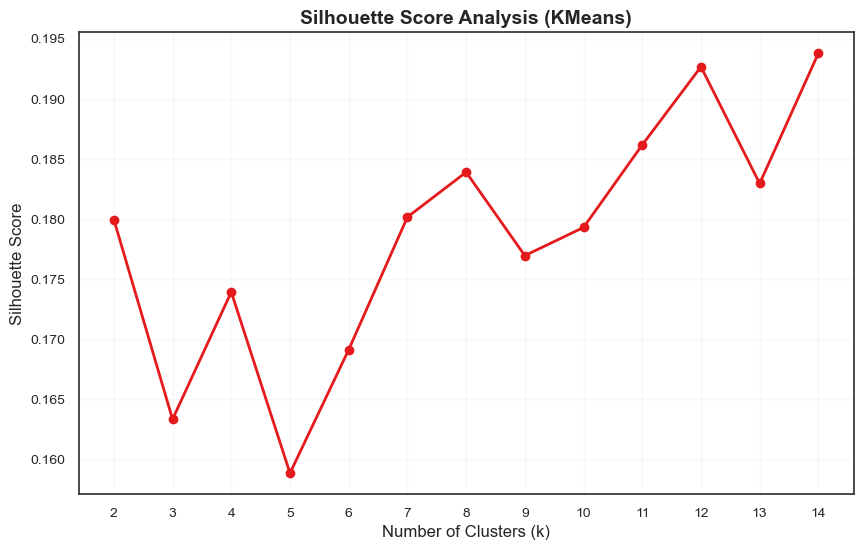

In [67]:
silhouette_scores = {}
k_range = range(2, 15)

print("Calculating Silhouette Scores...")

for k in k_range:
    # Set KMeans parameters
    kmeans.set_params(n_clusters=k, random_state=42)
    
    # Perform clustering
    labels = kmeans.fit_predict(df_demographic)
    
    # Compute silhouette score
    score = silhouette_score(df_demographic, labels)
    silhouette_scores[k] = score
    print(f"k={k}: {score:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
pd.Series(silhouette_scores).plot(marker="o")
plt.title("Silhouette Score Analysis (KMeans)", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

Although the silhouette score reaches higher values for larger numbers of clusters, the improvement becomes marginal beyond k ≈ 7. Considering the R²-based elbow analysis and the need for interpretability, a solution with six clusters was selected as the final clustering configuration.

In [68]:
k_best = 6

# 6. K-Means

In [77]:
# Inputs already done
# customers: final preprocessed df
# df_demographic: scaled df used for clustering
# demographic_features: list of features used for clustering

k_best = 6

# Fit final clustering model
kmeans_final = KMeans(
    n_clusters=k_best,
    init="k-means++",
    n_init=20,
    random_state=42
)
cluster_labels = kmeans_final.fit_predict(df_demographic[demographic_features])

# Prepare profiling dataframe
df_profile = df_demographic[demographic_features].copy()
df_profile["k_cluster"] = cluster_labels

# 7. Clusters Analysis

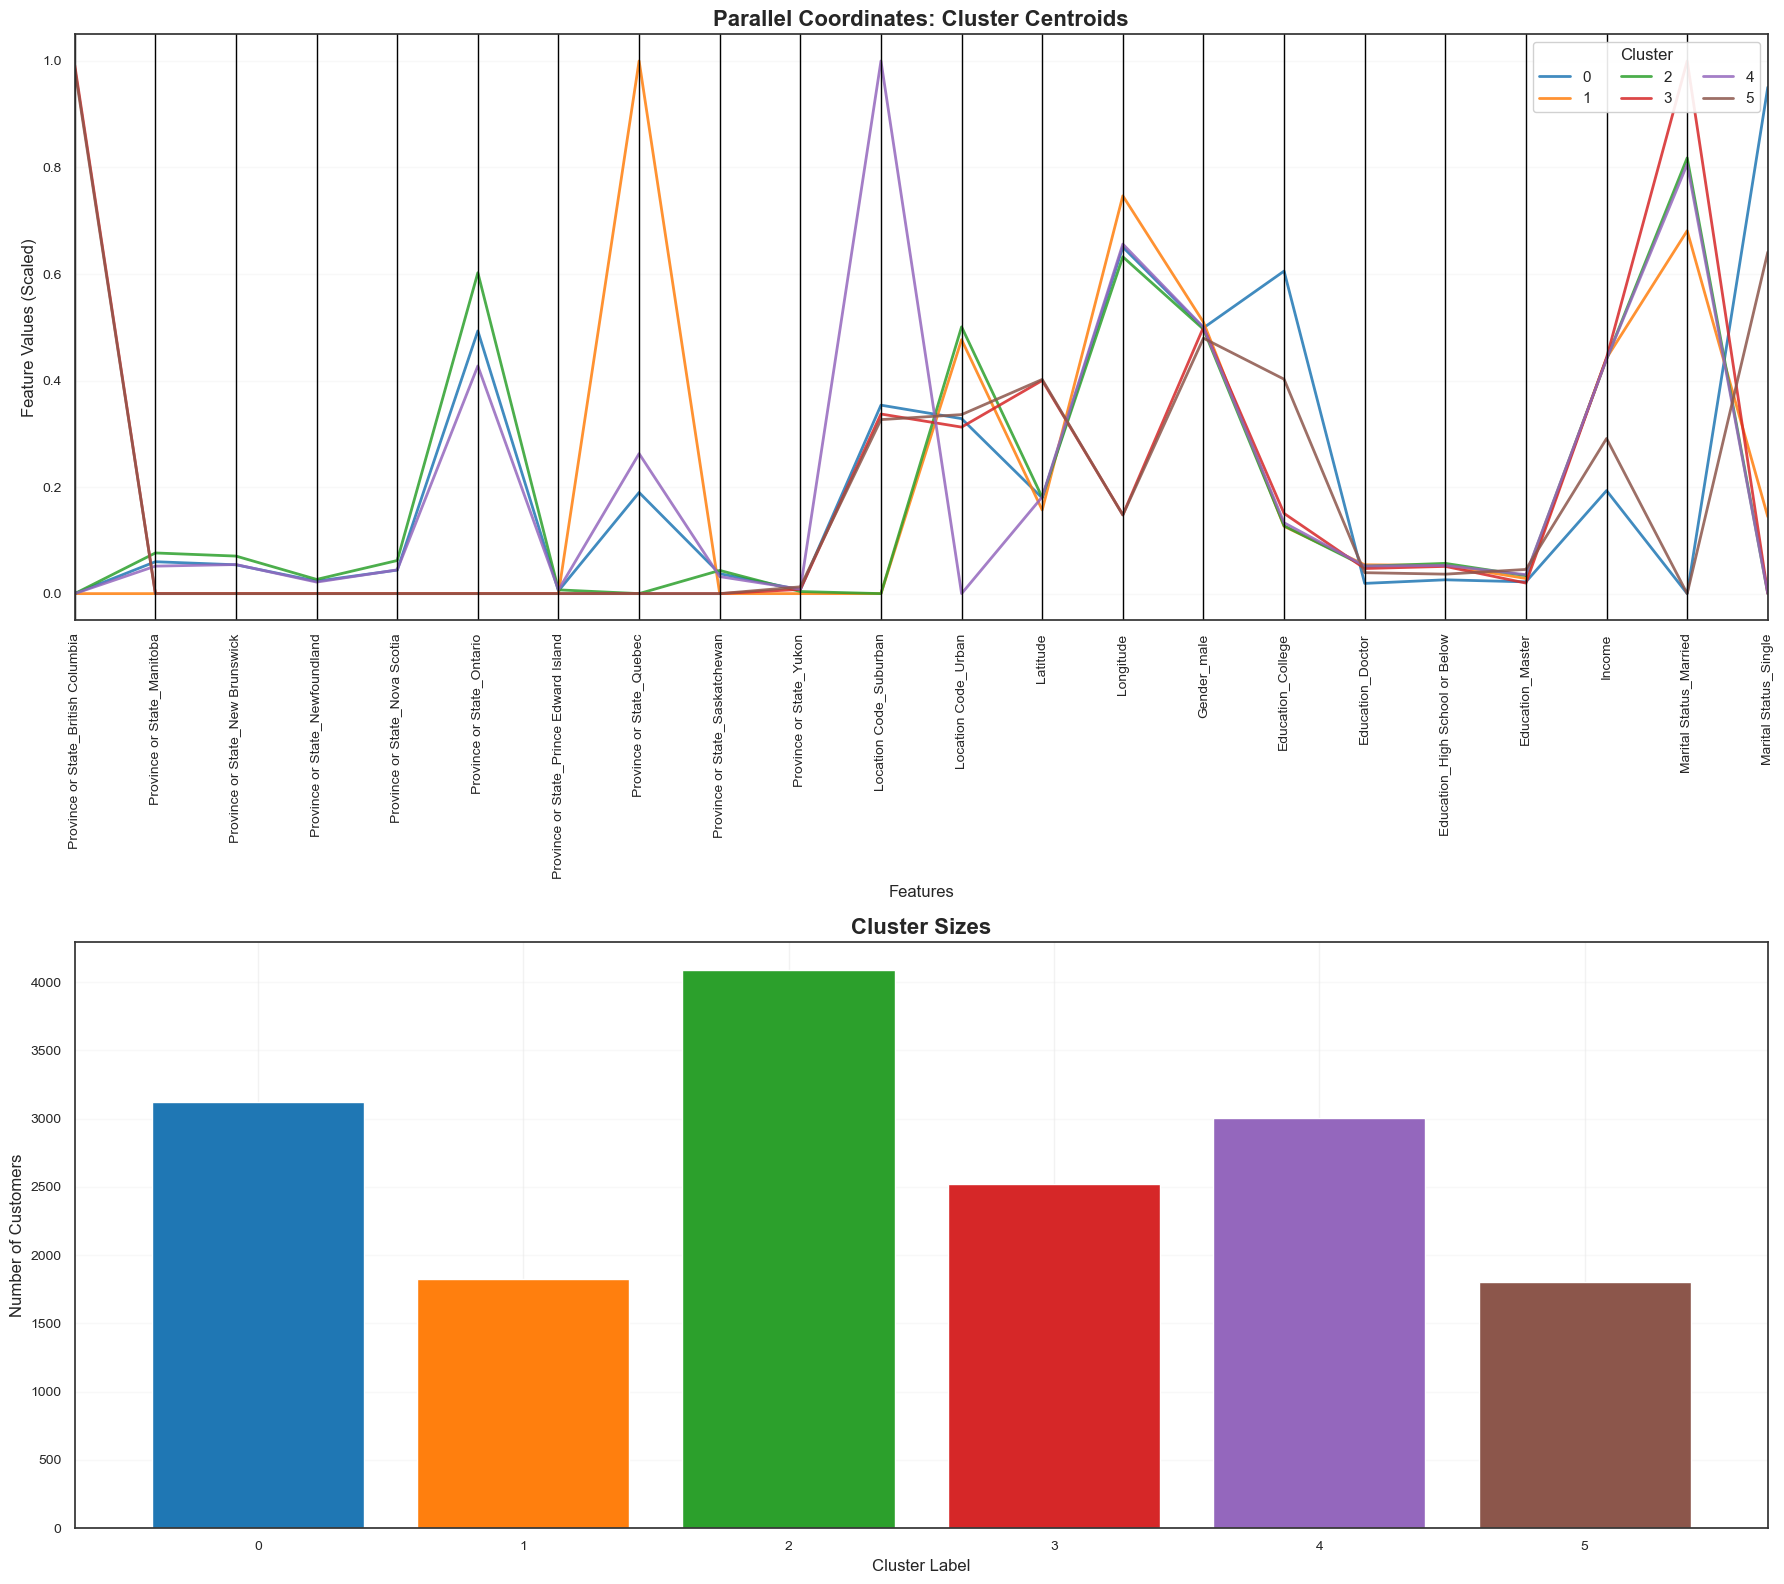

In [81]:
# Compute centroids (cluster means)
df_centroids = df_profile.groupby("k_cluster")[demographic_features].mean()

#  FIGURE SETUP 
fig = plt.figure(figsize=(18, 16))

# TOP PLOT: Parallel Coordinates
ax1 = plt.subplot(2, 1, 1)

pd.plotting.parallel_coordinates(
    df_centroids.reset_index(),
    "k_cluster",
    color=sns.color_palette("tab10", n_colors=k_best),
    ax=ax1,
    alpha=0.85
)

ax1.set_title("Parallel Coordinates: Cluster Centroids", fontsize=16, fontweight="bold")
ax1.set_ylabel("Feature Values (Scaled)", fontsize=12)
ax1.set_xlabel("Features", fontsize=12)

# Rotate labels for readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)

# Reduce visual noise
ax1.grid(True, alpha=0.3)
ax1.legend(title="Cluster", loc="upper right", ncol=3)

# BOTTOM PLOT: Cluster Sizes
ax2 = plt.subplot(2, 1, 2)

cluster_sizes = df_profile["k_cluster"].value_counts().sort_index()

ax2.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values,
    color=sns.color_palette("tab10", n_colors=k_best)
)

ax2.set_title("Cluster Sizes", fontsize=16, fontweight="bold")
ax2.set_xlabel("Cluster Label", fontsize=12)
ax2.set_ylabel("Number of Customers", fontsize=12)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:
# Count the number of customers in each cluster and display the result and plot it
cluster_counts = df_profile['k_cluster'].value_counts().sort_index()
print("Number of customers in each cluster:")
for cluster_label, count in cluster_counts.items():
    print(f"Cluster {cluster_label}: {count} customers")

Number of customers in each cluster:
Cluster 0: 3123 customers
Cluster 1: 1829 customers
Cluster 2: 4087 customers
Cluster 3: 2524 customers
Cluster 4: 3006 customers
Cluster 5: 1806 customers


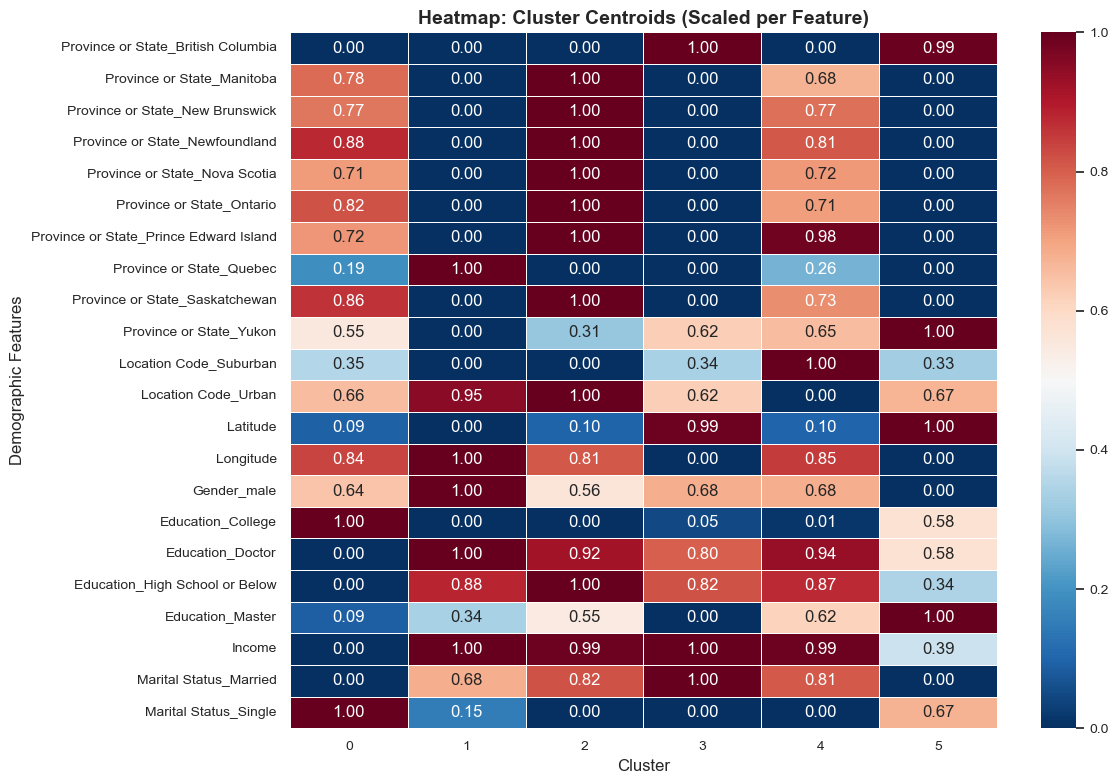

In [84]:
# Visualization: Heatmap of Cluster Centroids
plt.figure(figsize=(12, 8))

# Prepare data: features as rows
df_plot = df_centroids[demographic_features].T

# Min-Max scaling per feature across clusters (row-wise)
df_plot_scaled = df_plot.apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0,
    axis=1
)

# Heatmap
sns.heatmap(
    df_plot_scaled,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap: Cluster Centroids (Scaled per Feature)", fontsize=14, fontweight="bold")
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Demographic Features", fontsize=12)
plt.tight_layout()
plt.show()

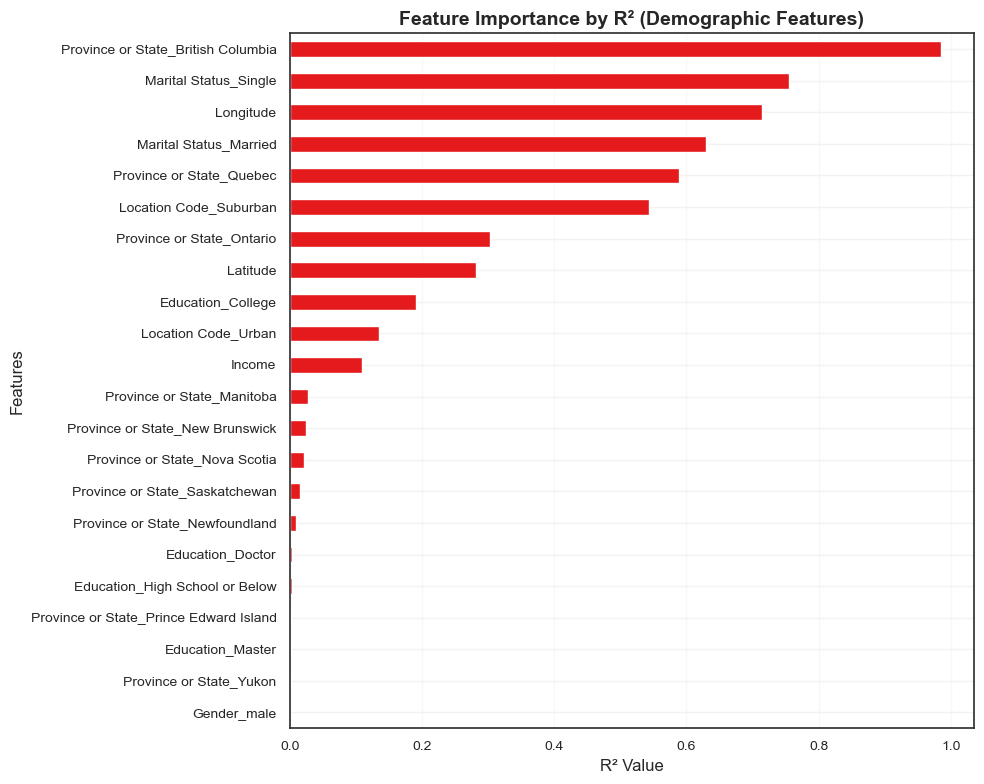

In [86]:
r2_data = {}

for feature in demographic_features:
    # get_rsq expects a list of features
    r2_data[feature] = get_rsq(df_profile, [feature], "k_cluster")

r2_feats = pd.Series(r2_data)

# Plot
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importance by R² (Demographic Features)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Feature-level R² was computed to quantify how strongly each demographic variable differentiates the obtained clusters. Higher R² values indicate features whose distributions vary substantially across clusters, thus contributing most to segment separation.

In [88]:
# Calculate R² for KMeans clustering
r2_km = get_rsq(df_profile, demographic_features, 'k_cluster')
print("R² for KMeans clustering:", r2_km)

R² for KMeans clustering: 0.3869221209479326


The final K-Means solution with six clusters explains approximately 38.7% of the variance in the demographic features, indicating a meaningful segmentation.

## 8. Hierachical Clustering

In [92]:
hier = AgglomerativeClustering(
    n_clusters=k_best,
    linkage='ward',         # same method used in the dendrogram
    metric='euclidean'      # distance measure
)

hier_labels = hier.fit_predict(df_demographic)
hier_labels

array([5, 3, 3, ..., 3, 4, 1])

## 9. Hierarchical Clustering vs K-Means Clustering

In [93]:
customers["k_cluster"] = cluster_labels
customers["k_cluster"].value_counts()

k_cluster
2    4087
0    3123
4    3006
3    2524
1    1829
5    1806
Name: count, dtype: int64

In [94]:
customers["hier_cluster"] = hier_labels
customers["hier_cluster"].value_counts()

hier_cluster
1    4447
2    3372
4    2666
0    2431
5    2216
3    1243
Name: count, dtype: int64

In [95]:
pd.crosstab(customers['k_cluster'], customers['hier_cluster'])

hier_cluster,0,1,2,3,4,5
k_cluster,,,,,,
0,1436,788,25,602,272,0
1,0,149,0,0,1680,0
2,665,1863,127,0,0,1432
3,0,317,2207,0,0,0
4,330,1094,80,4,714,784
5,0,236,933,637,0,0


## 2.8 Density based Clustering

We have done KMeans++ Clustering. Now we will do Density Based Clustering for Value Based Perspective. We will use DBSCAN and Mean Shift and GMM Algorithms for Density Based Clustering.

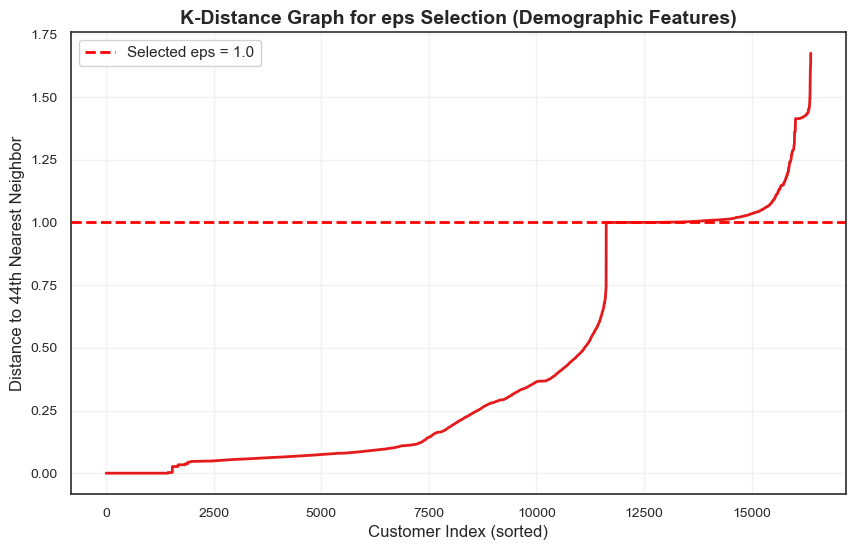

In [ ]:
# Rule of thumb: k ≈ 2 * n_features
k = df_demographic.shape[1] * 2

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(df_demographic)

distances, indices = neigh.kneighbors(df_demographic)

# Distance to the k-th nearest neighbor
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection (Demographic Features)")
plt.xlabel("Customer Index (sorted)")
plt.ylabel(f"Distance to {k}th Nearest Neighbor")
plt.grid(True)

# Optional: visually test a candidate eps
plt.axhline(y=1.0, color="r", linestyle="--", label="Candidate eps")

plt.legend()
plt.show()

In [ ]:
eps_values = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2]  
min_samples = 30

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = dbscan.fit_predict(df_demographic)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    pct_noise = (n_noise / df_demographic.shape[0]) * 100

    results.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "pct_noise": pct_noise
    })

results_df = pd.DataFrame(results).sort_values(["n_clusters", "pct_noise"], ascending=[False, True])
results_df

,eps,min_samples,n_clusters,n_noise,pct_noise
0,0.7,30,119,4044,24.696183
1,0.8,30,119,4044,24.696183
2,0.9,30,119,4044,24.696183
3,1.0,30,46,3230,19.725191
4,1.1,30,5,116,0.708397
5,1.2,30,3,80,0.488550


In [111]:
best_eps = 1.1

dbscan = DBSCAN(eps=best_eps, min_samples=30, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(df_demographic)

print("DBSCAN found", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0), "clusters")
np.unique(dbscan_labels)

n_noise = np.sum(dbscan_labels == -1)
print(f"Number of noise points: {n_noise} out of {df_demographic.shape[0]} total points.")

percentage_noise = (n_noise / df_demographic.shape[0]) * 100
print(f"Percentage of noise points: {percentage_noise:.2f}%")

df_concat = pd.concat(
    [df_demographic,
     pd.Series(dbscan_labels, name="dbscan_labels", index=df_demographic.index)],
    axis=1
)

df_concat


DBSCAN found 5 clusters
Number of noise points: 116 out of 16375 total points.
Percentage of noise points: 0.71%


,Latitude,Longitude,Income,Province or State_British Columbia,Province or State_Manitoba,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,...,Location Code_Suburban,Location Code_Urban,Gender_male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,dbscan_labels
0,0.037680,0.676108,0.701593,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,True,False,0
1,0.595360,0.261899,0.000000,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,0
2,0.355081,0.144954,0.000000,True,False,False,False,False,False,False,...,False,True,True,True,False,False,False,False,True,0
3,0.037680,0.676108,0.000000,False,False,False,False,False,True,False,...,True,False,True,True,False,False,False,False,True,0
4,0.137786,0.720675,0.978506,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16370,0.355081,0.144954,0.000000,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,0
16371,0.420623,0.369643,0.783249,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
16372,0.355081,0.144954,0.000000,True,False,False,False,False,False,False,...,False,True,True,True,False,False,False,False,True,0
16373,0.141899,0.746738,0.589692,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,1


In [112]:
df_concat['dbscan_labels'].value_counts().sort_index()

dbscan_labels
-1      116
 0    11685
 1     3212
 2      621
 3      526
 4      215
Name: count, dtype: int64

DBSCAN identified a small proportion of customers as noise (label −1), corresponding to observations that do not belong to any dense region. This indicates the presence of atypical demographic profiles.

In [113]:
116 / df_demographic.shape[0] * 100

0.7083969465648855

DBSCAN identified five dense demographic clusters while classifying only 0.7% of observations as noise, indicating a stable density structure with limited outliers.

In [114]:
mask = dbscan_labels != -1

n_clusters = len(set(dbscan_labels)) - 1  # porque já sabemos que existe -1

if n_clusters > 1:
    silhouette_avg = silhouette_score(
        df_demographic[mask],
        dbscan_labels[mask]
    )
    print(f"Silhouette Score for DBSCAN clustering (excluding noise): {silhouette_avg:.4f}")
else:
    print("Not enough clusters to calculate Silhouette Score.")

Silhouette Score for DBSCAN clustering (excluding noise): 0.1318


The silhouette score was computed excluding noise points to assess the internal cohesion and separation of DBSCAN clusters. As expected for density-based clustering, the score is lower than partition-based methods but still indicates meaningful structure.
The silhouette score obtained for DBSCAN clustering was 0.13. Although lower than scores typically observed for partition-based methods, this result is expected for density-based clustering on demographic data, which tends to exhibit smooth distributions rather than well-separated clusters.